In [ ]:
# @title 1. Dataset Scope and Record Granularity (REVISED FULL CODE)
# -*- coding: utf-8 -*-

import requests
import json
import pandas as pd
import numpy as np

# ==========================================
# 1. ROBUST DATA LOADING FUNCTIONS
# ==========================================
def load_json_from_github(url):
    """Loads a JSON file from a given GitHub raw URL with error handling."""
    try:
        response = requests.get(url)
        response.raise_for_status()
        return json.loads(response.text)
    except requests.exceptions.RequestException as e:
        print(f"Error loading data from {url}: {e}")
        return []
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from {url}: {e}")
        return []

# URLs
similes_url = 'https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/similes_data.json'
metaphors_url = 'https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/metaphors_data.json'

print(">>> Loading datasets...")
similes_data = load_json_from_github(similes_url)
metaphors_data = load_json_from_github(metaphors_url)

if not similes_data or not metaphors_data:
    print("!!! Failed to load data. Exiting.")
    exit()

print(f"✓ Loaded Raw Files: Similes ({len(similes_data)}), Metaphors ({len(metaphors_data)})")


# ==========================================
# 2. STRUCTURAL PROCESSING (Records vs Instances)
# ==========================================

def calculate_layer_depth(instance):
    """Calculates how many semantic layers are populated in a specific rhetorical instance."""
    populated = 0

    # 1. Identity & Classification
    if 'classification' in instance: populated += 1
    if instance.get('classification', {}).get('processing_effort'): populated += 1

    # 2. Components (Detailed check)
    comps = instance.get('components', {})
    if comps.get('subject'): populated += 1
    if comps.get('image'): populated += 1
    if comps.get('source_domain'): populated += 1
    if comps.get('target_domain'): populated += 1
    if comps.get('sensory_mode'): populated += 1
    if comps.get('tool') or comps.get('tool_types'): populated += 1

    # 3. Syntactic
    if 'syntactic_structure' in instance: populated += 1

    # 4. Pragmatics
    if 'functions' in instance and len(instance['functions']) > 0: populated += 1

    # 5. Imagery
    if 'imagery_and_aesthetics' in instance: populated += 1

    # 6. Symbolism
    if 'symbolism_and_implications' in instance: populated += 1

    # 7. Comparative
    if 'comparative_analysis' in instance: populated += 1

    # 8. Scholarly
    if 'scholarly_interpretations' in instance: populated += 1

    # Base layers (Metadata + Preamble inherited from record context)
    populated += 2

    return populated

def process_corpus_structure(s_data, m_data):
    """
    Separates the concept of 'Unique Verse Records' from 'Rhetorical Instances'.
    """
    unique_records_map = {} # Key: chapter_verse, Value: {text, token_count, unique_tokens}
    all_instances = []      # List of all rhetorical objects

    # Helper to process a list of raw records
    def process_batch(data_list, label_type):
        for rec in data_list:
            # --- Record Level Logic ---
            meta = rec.get('metadata', {})
            chap = meta.get('chapter_no')
            verse = meta.get('verse_no')
            rec_key = f"{chap}:{verse}"

            # Text Processing (Only if record not seen yet, to avoid double counting tokens)
            if rec_key not in unique_records_map:
                text = meta.get('ayah_text_uthmani', '')
                tokens = text.split()
                unique_records_map[rec_key] = {
                    'text_len': len(text),
                    'token_count': len(tokens),
                    'unique_tokens': set(tokens)
                }

            # --- Instance Level Logic ---
            ra = rec.get('rhetorical_analysis', {})
            # Extract list of instances (handling different naming conventions)
            instances = ra.get('similes', []) if 'similes' in ra else ra.get('metaphors', [])

            if not instances and 'figurative_instances' in ra:
                instances = ra['figurative_instances']

            for inst in instances:
                depth = calculate_layer_depth(inst)
                all_instances.append({
                    'type': label_type,
                    'record_key': rec_key,
                    'depth': depth
                })

    # Run processing
    process_batch(s_data, 'Simile')
    process_batch(m_data, 'Metaphor')

    return unique_records_map, pd.DataFrame(all_instances)

# Execute Processing
records_map, df_instances = process_corpus_structure(similes_data, metaphors_data)

# ==========================================
# 3. STATISTICS CALCULATION
# ==========================================

# A. Record Stats
total_unique_records = len(records_map)

# B. Instance Stats
total_instances = len(df_instances)
similes_count = len(df_instances[df_instances['type'] == 'Simile'])
metaphors_count = len(df_instances[df_instances['type'] == 'Metaphor'])

# Percentages
pct_similes = (similes_count / total_instances) * 100
pct_metaphors = (metaphors_count / total_instances) * 100

# C. Granularity
avg_layers = df_instances['depth'].mean()
sd_layers = df_instances['depth'].std()
annotation_density = total_instances / total_unique_records

# D. Lexical Stats (Aggregated from Unique Records)
total_tokens = sum(r['token_count'] for r in records_map.values())

# Global Vocabulary (Union of all sets)
global_vocab = set()
for r in records_map.values():
    global_vocab.update(r['unique_tokens'])

vocab_size = len(global_vocab)
ttr = vocab_size / total_tokens if total_tokens > 0 else 0


# ==========================================
# 4. PRINT RESULTS
# ==========================================

print("\n" + "="*50)
print("   UPDATED DATASET STATISTICS (Section 1)   ")
print("="*50)

print(f"\n1. DATASET SCOPE:")
print(f"   - Unique Verse Records: {total_unique_records}")
print(f"   - Total Rhetorical Instances: {total_instances}")
print(f"   - Annotation Density: {annotation_density:.3f} instances/record")

print(f"\n2. INSTANCE BREAKDOWN:")
print(f"   - Similes: {similes_count} ({pct_similes:.1f}%)")
print(f"   - Metaphors: {metaphors_count} ({pct_metaphors:.1f}%)")

print(f"\n3. GRANULARITY & DEPTH:")
print(f"   - Avg. Layers per Instance: {avg_layers:.2f} (SD={sd_layers:.2f})")
print(f"   - Max Depth Observed: {df_instances['depth'].max()}")

print(f"\n4. LEXICAL METRICS:")
print(f"   - Total Tokens: {total_tokens:,}")
print(f"   - Vocabulary Size: {vocab_size:,}")
print(f"   - Type-Token Ratio (TTR): {ttr:.3f}")

print("\n" + "="*50)
print("   LATEX TABLE VALUES   ")
print("="*50)
print(f"% Unique Records")
print(f"{total_unique_records}")
print(f"% Total Instances")
print(f"{total_instances}")
print(f"% Similes")
print(f"{similes_count} ({pct_similes:.1f}\\%)")
print(f"% Metaphors")
print(f"{metaphors_count} ({pct_metaphors:.1f}\\%)")
print(f"% Avg Layers")
print(f"{avg_layers:.1f} ($\\pm {sd_layers:.1f}$)")
print(f"% Annotation Density")
print(f"{annotation_density:.3f}")

>>> Loading datasets...
✓ Loaded Raw Files: Similes (402), Metaphors (965)

   UPDATED DATASET STATISTICS (Section 1)   

1. DATASET SCOPE:
   - Unique Verse Records: 1259
   - Total Rhetorical Instances: 1402
   - Annotation Density: 1.114 instances/record

2. INSTANCE BREAKDOWN:
   - Similes: 408 (29.1%)
   - Metaphors: 994 (70.9%)

3. GRANULARITY & DEPTH:
   - Avg. Layers per Instance: 15.29 (SD=0.45)
   - Max Depth Observed: 16

4. LEXICAL METRICS:
   - Total Tokens: 20,524
   - Vocabulary Size: 8,107
   - Type-Token Ratio (TTR): 0.395

   LATEX TABLE VALUES   
% Unique Records
1259
% Total Instances
1402
% Similes
408 (29.1\%)
% Metaphors
994 (70.9\%)
% Avg Layers
15.3 ($\pm 0.5$)
% Annotation Density
1.114


>>> Attempting to load Similes...
✓ Similes loaded successfully. Records: 402
>>> Attempting to load Metaphors...
✓ Metaphors loaded successfully. Records: 965
----------------------------------------
Records Successfully Extracted:
   - Similes:   408
   - Metaphors: 994
----------------------------------------

   MODULE A: METAPHOR STRUCTURAL ENGINEERING
>>> Metaphor Syntactic Distribution:
structural_class
Verbal Structure     44.47%
Nominal Structure    32.19%
Clausal/Sentential   12.47%
Complex/Composite     5.84%
Other                 5.03%

>>> Specific Verbal Bias (Past+Imp): 37.93%

   MODULE B: SIMILE TOOL ENGINEERING
>>> Simile Tool Distribution:
tool_category
Explicit Particle      65.93%
Implicit (Zero-Shot)   26.47%
Structural              4.90%
Other                   2.70%

>>> 'Ka' Particle Variants Ratio: 65.20%

>>> Generating Professional Plots...


/tmp/ipython-input-2114901473.py:207: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Count', data=m_plot_data,
/tmp/ipython-input-2114901473.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Count', data=s_plot_data,


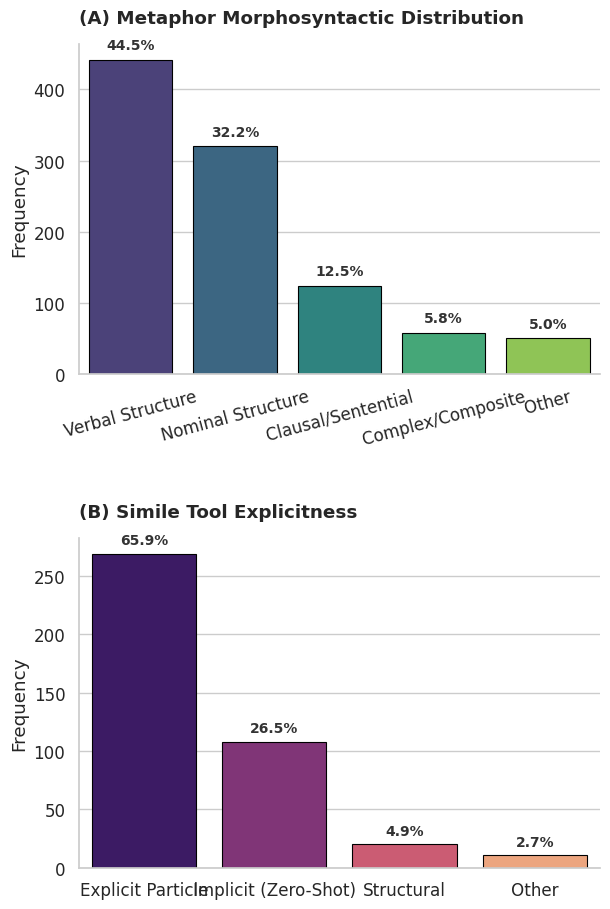


   LATEX TABLE SNIPPET
\begin{table}[ht]
    \centering
    \caption{Structural Distribution Analysis}
    \begin{tabular}{lcc}
        \toprule
        \textbf{Category} & \textbf{Count} & \textbf{Pct} \\
        \midrule
        \textit{Metaphors} & & \\
        Verbal Structure & 442 & 44.5\% \\
        Nominal Structure & 320 & 32.2\% \\
        Clausal/Sentential & 124 & 12.5\% \\
        Complex/Composite & 58 & 5.8\% \\
        Other & 50 & 5.0\% \\
        \midrule
        \textit{Similes} & & \\
        Explicit Particle & 269 & 65.9\% \\
        Implicit (Zero-Shot) & 108 & 26.5\% \\
        Structural & 20 & 4.9\% \\
        Other & 11 & 2.7\% \\
        \bottomrule
    \end{tabular}
\end{table}


In [ ]:
# @title 2. Figurative Mechanism Distribution (Robust v3.1 - Schema Adaptive)
# -*- coding: utf-8 -*-
# =============================================================================
# IEEE Access: Robust Figurative Language Analysis Pipeline v3.1
# =============================================================================

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

# -----------------------------------------------------------------------------
# 1. ROBUST DATA LOADING (Production-Safe)
# -----------------------------------------------------------------------------
URLS = {
    "similes": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/similes_data.json",
    "metaphors": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/metaphors_data.json"
}

def load_dataset_robust(url, name, timeout=60):
    print(f">>> Attempting to load {name}...")

    session = requests.Session()
    retry_strategy = Retry(
        total=5,
        backoff_factor=1,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"]
    )

    adapter = HTTPAdapter(max_retries=retry_strategy)
    session.mount("https://", adapter)
    session.mount("http://", adapter)

    try:
        response = session.get(url, timeout=timeout, stream=True)
        response.raise_for_status()

        content = response.content
        if not content or len(content) < 100:
            raise ValueError("Downloaded content appears incomplete.")

        text = content.decode("utf-8")
        data = json.loads(text)

        print(f"✓ {name} loaded successfully. Records: {len(data)}")
        return data

    except json.JSONDecodeError as e:
        print(f"!!! JSON Decode Error in {name}")
        print(f"Line: {e.lineno}, Column: {e.colno}")

        error_pos = e.pos
        start = max(0, error_pos - 200)
        end = min(len(text), error_pos + 200)
        print("\n--- Context Around Error ---")
        print(text[start:end])
        print("----------------------------")
        return []

    except Exception as e:
        print(f"!!! Network/Request Error for {name}: {e}")
        return []

raw_similes = load_dataset_robust(URLS["similes"], "Similes")
raw_metaphors = load_dataset_robust(URLS["metaphors"], "Metaphors")

# -----------------------------------------------------------------------------
# 2. FLATTENING & FEATURE EXTRACTION (Schema-Adaptive)
# -----------------------------------------------------------------------------
def process_data(records, mode):
    extracted_features = []
    if not records:
        return pd.DataFrame()

    for rec in records:
        ra = rec.get('rhetorical_analysis', {})

        # Auto-detect figurative key
        possible_keys = ['similes', 'metaphors', 'figurative_instances']
        instances = []

        for key in possible_keys:
            if key in ra and isinstance(ra[key], list):
                instances = ra[key]
                break

        for inst in instances:
            comps = inst.get('components', {})
            cls = inst.get('classification', {})

            row = {
                'id': inst.get('id'),
                'mode': mode,
                'main_type': cls.get('main_type', 'Unknown'),
                'ling_form': comps.get('metaphor_linguistic_form', 'Unknown'),
                'tool_type': comps.get('tool_types', 'Unknown'),
                'image_type': comps.get('image', 'Normal')
            }
            extracted_features.append(row)

    return pd.DataFrame(extracted_features)

df_s = process_data(raw_similes, 'Simile')
df_m = process_data(raw_metaphors, 'Metaphor')

print("-" * 40)
print("Records Successfully Extracted:")
print(f"   - Similes:   {len(df_s)}")
print(f"   - Metaphors: {len(df_m)}")
print("-" * 40)

# -----------------------------------------------------------------------------
# 3. ANALYSIS
# -----------------------------------------------------------------------------

# ------------------- METAPHOR ENGINEERING -------------------
if not df_m.empty:
    print("\n" + "="*60)
    print("   MODULE A: METAPHOR STRUCTURAL ENGINEERING")
    print("="*60)

    def categorize_form(f):
        f = str(f).lower()
        if any(x in f for x in ['verbal', 'past', 'imperfect', 'passive']):
            return 'Verbal Structure'
        elif any(x in f for x in ['nominal', 'idafa', 'adj']):
            return 'Nominal Structure'
        elif 'clausal' in f:
            return 'Clausal/Sentential'
        elif any(x in f for x in ['extended', 'blend', 'complex']):
            return 'Complex/Composite'
        else:
            return 'Other'

    df_m['structural_class'] = df_m['ling_form'].apply(categorize_form)

    m_counts = df_m['structural_class'].value_counts()
    m_stats = df_m['structural_class'].value_counts(normalize=True) * 100

    print(">>> Metaphor Syntactic Distribution:")
    print(m_stats.to_string(float_format="%.2f%%"))

    verbal_forms = ['verbal_past', 'verbal_imperfect']
    verbal_exact = df_m[df_m['ling_form'].isin(verbal_forms)]

    print(f"\n>>> Specific Verbal Bias (Past+Imp): {len(verbal_exact)/len(df_m)*100:.2f}%")

# ------------------- SIMILE ENGINEERING -------------------
if not df_s.empty:
    print("\n" + "="*60)
    print("   MODULE B: SIMILE TOOL ENGINEERING")
    print("="*60)

    def analyze_tool(t):
        t = str(t).lower()
        if 'particle' in t:
            return 'Explicit Particle'
        elif 'implicit' in t:
            return 'Implicit (Zero-Shot)'
        elif 'structure' in t:
            return 'Structural'
        else:
            return 'Other'

    df_s['tool_category'] = df_s['tool_type'].apply(analyze_tool)

    s_counts = df_s['tool_category'].value_counts()
    s_stats = df_s['tool_category'].value_counts(normalize=True) * 100

    print(">>> Simile Tool Distribution:")
    print(s_stats.to_string(float_format="%.2f%%"))

    ka_variants = df_s[df_s['tool_type'].astype(str).str.contains('ka', case=False)]
    print(f"\n>>> 'Ka' Particle Variants Ratio: {len(ka_variants)/len(df_s)*100:.2f}%")

else:
    print("\n!!! SKIPPING SIMILE ANALYSIS: No data available.")

# -----------------------------------------------------------------------------
# 4. PLOTTING
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# 4. PLOTTING (Refined for IEEE Column Width)
# -----------------------------------------------------------------------------
if not df_m.empty and not df_s.empty:
    print("\n>>> Generating Professional Plots...")

    # Set style for academic publication
    sns.set_theme(style="whitegrid", font_scale=1.1)

    # Create Figure with 2 rows, 1 column (Vertical Stack)
    # Size (7, 10) ensures readability when resized to single column width
    fig, axes = plt.subplots(2, 1, figsize=(7, 10), sharex=False)

    # ------------------- PLOT 1: METAPHOR MORPHOSYNTAX -------------------
    # Prepare Data
    m_plot_data = df_m['structural_class'].value_counts().reset_index()
    m_plot_data.columns = ['Category', 'Count']
    m_plot_data['Percentage'] = (m_plot_data['Count'] / len(df_m) * 100)

    # Plot
    sns.barplot(x='Category', y='Count', data=m_plot_data,
                palette='viridis', ax=axes[0], edgecolor='black', linewidth=0.8)

    axes[0].set_title('(A) Metaphor Morphosyntactic Distribution',
                      fontweight='bold', pad=15, loc='left')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Frequency')

    # Add Percentage Labels
    for i, p in enumerate(axes[0].patches):
        height = p.get_height()
        axes[0].text(p.get_x() + p.get_width() / 2., height + 15,
                     f'{m_plot_data["Percentage"][i]:.1f}%',
                     ha="center", fontsize=10, fontweight='bold', color='#333333')

    # Rotate X-labels slightly to prevent overlap
    axes[0].tick_params(axis='x', rotation=15)

    # ------------------- PLOT 2: SIMILE TOOL EXPLICITNESS -------------------
    # Prepare Data
    s_plot_data = df_s['tool_category'].value_counts().reset_index()
    s_plot_data.columns = ['Category', 'Count']
    s_plot_data['Percentage'] = (s_plot_data['Count'] / len(df_s) * 100)

    # Plot
    sns.barplot(x='Category', y='Count', data=s_plot_data,
                palette='magma', ax=axes[1], edgecolor='black', linewidth=0.8)

    axes[1].set_title('(B) Simile Tool Explicitness',
                      fontweight='bold', pad=15, loc='left')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Frequency')

    # Add Percentage Labels
    for i, p in enumerate(axes[1].patches):
        height = p.get_height()
        axes[1].text(p.get_x() + p.get_width() / 2., height + 8,
                     f'{s_plot_data["Percentage"][i]:.1f}%',
                     ha="center", fontsize=10, fontweight='bold', color='#333333')

    # Final Adjustments
    sns.despine()
    plt.tight_layout(pad=3.0) # Add padding between plots

    # Save functionality (Optional)
    plt.savefig('structural_distribution_vertical.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# -----------------------------------------------------------------------------
# 5. LATEX TABLE GENERATION
# -----------------------------------------------------------------------------
print("\n" + "="*60)
print("   LATEX TABLE SNIPPET")
print("="*60)

print(r"\begin{table}[ht]")
print(r"    \centering")
print(r"    \caption{Structural Distribution Analysis}")
print(r"    \begin{tabular}{lcc}")
print(r"        \toprule")
print(r"        \textbf{Category} & \textbf{Count} & \textbf{Pct} \\")
print(r"        \midrule")

if not df_m.empty:
    print(r"        \textit{Metaphors} & & \\")
    for idx, val in m_counts.items():
        pct = (val / len(df_m)) * 100
        print(f"        {idx} & {val} & {pct:.1f}\\% \\\\")

if not df_s.empty:
    print(r"        \midrule")
    print(r"        \textit{Similes} & & \\")
    for idx, val in s_counts.items():
        pct = (val / len(df_s)) * 100
        print(f"        {idx} & {val} & {pct:.1f}\\% \\\\")

print(r"        \bottomrule")
print(r"    \end{tabular}")
print(r"\end{table}")


In [ ]:
# @title 3. Semantic Domain Coverage

# =============================================================================
# IEEE Access: Semantic Domain Analysis Pipeline (Robust v2.0)
# =============================================================================

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from scipy.stats import entropy

# -----------------------------------------------------------------------------
# 1. ROBUST DATA LOADING
# -----------------------------------------------------------------------------

URLS = {
    "similes": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/similes_data.json",
    "metaphors": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/metaphors_data.json"
}

def load_data_robust(url, name):
    print(f">>> Loading {name}...")

    session = requests.Session()
    retry = Retry(total=5, backoff_factor=1,
                  status_forcelist=[429,500,502,503,504])
    adapter = HTTPAdapter(max_retries=retry)
    session.mount("https://", adapter)

    try:
        r = session.get(url, timeout=60, stream=True)
        r.raise_for_status()

        text = r.content.decode("utf-8")
        data = json.loads(text)

        print(f"✓ {name} loaded: {len(data)} records")
        return data

    except Exception as e:
        print(f"Error loading {name}: {e}")
        return []

raw_s = load_data_robust(URLS["similes"], "Similes")
raw_m = load_data_robust(URLS["metaphors"], "Metaphors")

# -----------------------------------------------------------------------------
# 2. SCHEMA-ADAPTIVE DOMAIN EXTRACTION
# -----------------------------------------------------------------------------

def extract_domains(records, dataset_type):

    rows = []

    for rec in records:
        ra = rec.get('rhetorical_analysis', {})

        # auto-detect key
        possible_keys = ['similes', 'metaphors', 'figurative_instances']
        instances = []

        for key in possible_keys:
            if key in ra and isinstance(ra[key], list):
                instances = ra[key]
                break

        for inst in instances:
            comps = inst.get('components', {})

            s_dom = comps.get('source_domain', 'Unknown')
            t_dom = comps.get('target_domain', 'Unknown')

            if isinstance(s_dom, list):
                s_dom = s_dom[0] if s_dom else 'Unknown'
            if isinstance(t_dom, list):
                t_dom = t_dom[0] if t_dom else 'Unknown'

            rows.append({
                'Dataset': dataset_type,
                'Source_Domain': str(s_dom).strip(),
                'Target_Domain': str(t_dom).strip()
            })

    df = pd.DataFrame(rows)

    if df.empty:
        print(f"⚠ WARNING: {dataset_type} extraction produced empty DataFrame")

    return df


df_s = extract_domains(raw_s, 'Simile')
df_m = extract_domains(raw_m, 'Metaphor')
df_all = pd.concat([df_s, df_m], ignore_index=True)

# -----------------------------------------------------------------------------
# 3. METRIC ENGINE
# -----------------------------------------------------------------------------

def calculate_domain_metrics(df, col_name, label):

    if df.empty:
        print(f"\n⚠ Skipping {label}: No data available.")
        return None

    print(f"\n{'='*20} {label} ANALYSIS {'='*20}")

    counts = df[col_name].value_counts()
    total = len(df)

    probs = counts / total
    ent = entropy(probs, base=2)

    print(f"1. Shannon Entropy: {ent:.4f} bits")

    print("2. Top 5 Domains:")
    for dom, val in counts.head(5).items():
        print(f"   - {dom}: {val/total*100:.2f}%")

    tail = counts[probs < 0.01]
    print("3. Tail Analysis (<1%):")
    print(f"   - Tail Classes: {len(tail)}")
    print(f"   - Tail Mass: {tail.sum()/total*100:.2f}%")

    return counts


print("\n>>> DATASET: SIMILES")
s_source = calculate_domain_metrics(df_s, 'Source_Domain', 'SIMILE SOURCE DOMAIN')
s_target = calculate_domain_metrics(df_s, 'Target_Domain', 'SIMILE TARGET DOMAIN')

print("\n>>> DATASET: METAPHORS")
m_source = calculate_domain_metrics(df_m, 'Source_Domain', 'METAPHOR SOURCE DOMAIN')
m_target = calculate_domain_metrics(df_m, 'Target_Domain', 'METAPHOR TARGET DOMAIN')


>>> Loading Similes...
✓ Similes loaded: 402 records
>>> Loading Metaphors...
✓ Metaphors loaded: 965 records

>>> DATASET: SIMILES

==================== SIMILE SOURCE DOMAIN ANALYSIS ====================
1. Shannon Entropy: 4.2879 bits
2. Top 5 Domains:
   - HISTORY_AND_TRADITION: 16.67%
   - FAMILY_AND_SOCIETY: 7.84%
   - NATURE_FLORA: 7.35%
   - BODY_AND_PHYSIOLOGY: 7.11%
   - DIVINE_LAWS: 6.13%
3. Tail Analysis (<1%):
   - Tail Classes: 10
   - Tail Mass: 4.41%

==================== SIMILE TARGET DOMAIN ANALYSIS ====================
1. Shannon Entropy: 2.8949 bits
2. Top 5 Domains:
   - SPIRITUAL_PSYCHOLOGY: 17.65%
   - HUMAN_AGENTS_AND_GROUPS: 17.40%
   - ESCHATOLOGY: 15.69%
   - DEEDS_AND_BEHAVIOR: 14.95%
   - THEOLOGY: 13.48%
3. Tail Analysis (<1%):
   - Tail Classes: 0
   - Tail Mass: 0.00%

>>> DATASET: METAPHORS

==================== METAPHOR SOURCE DOMAIN ANALYSIS ====================
1. Shannon Entropy: 3.8428 bits
2. Top 5 Domains:
   - BODY_AND_PHYSIOLOGY: 16.30%
   - FAM

Loaded: Similes=402, Metaphors=965

   UPDATED METRICS (Content-Aware)   
Similes (408): ADI=68.9, Comp=99.5%, Schol=99.5%
Metaphors (994): ADI=66.5, Comp=99.2%, Schol=100.0%
Overall (1402): ADI=67.2, Comp=99.3%, Schol=99.9%


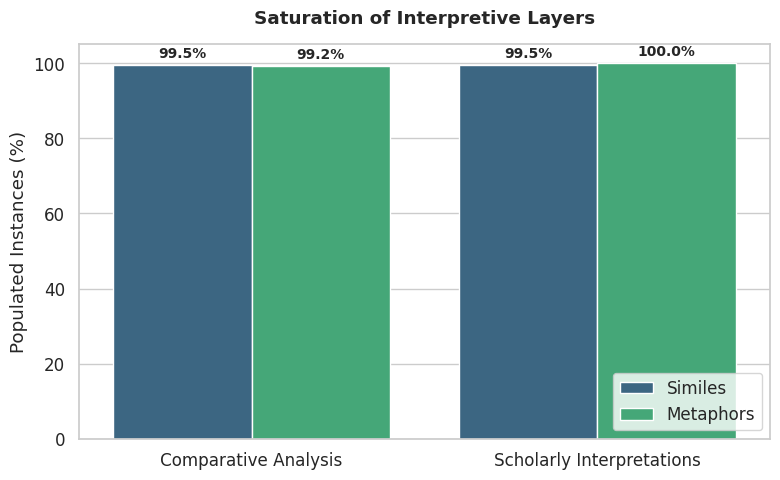


   LATEX TABLE CODE   

\begin{table}[ht]
    \centering
    \caption{Structural Annotation Depth and Semantic Density Metrics}
    \label{tab:annotation_depth}
    \begin{tabular}{lccc}
        \toprule
        \textbf{Metric} & \textbf{Similes} & \textbf{Metaphors} & \textbf{Overall} \\
        \midrule
        \multicolumn{4}{l}{\textit{Hierarchical Structure}} \\
        Avg. Core Layers (Max=6) & 6.00 & 6.00 & 6.00 \\
        Comparative Analysis Coverage & 99.5\% & 99.2\% & 99.3\% \\
        Scholarly Interpretation Coverage & 99.5\% & 100.0\% & 99.9\% \\
        \midrule
        \multicolumn{4}{l}{\textit{Relational Cardinality (Avg. per Instance)}} \\
        Pragmatic Functions & 3.00 & 2.91 & 2.94 \\
        Symbolic Implications & 2.98 & 2.75 & 2.82 \\
        Expert Opinions & 3.73 & 3.38 & 3.48 \\
        \midrule
        \multicolumn{4}{l}{\textit{Information Density}} \\
        Annotation Density Index (ADI) & \textbf{68.9} & 66.5 & \textbf{67.2} \\
        \bottomrule

In [2]:
# @title 4. Structural Annotation Depth & Visualization (Final Robust Version)
# -*- coding: utf-8 -*-

import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DATA LOADING
# ==========================================
URLS = {
    "similes": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/similes_data.json",
    "metaphors": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/metaphors_data.json"
}

def load_data(url):
    try:
        r = requests.get(url)
        r.raise_for_status()
        return json.loads(r.text)
    except Exception as e:
        print(f"Error loading {url}: {e}")
        return []

raw_s = load_data(URLS["similes"])
raw_m = load_data(URLS["metaphors"])

print(f"Loaded: Similes={len(raw_s)}, Metaphors={len(raw_m)}")

# ==========================================
# 2. ANALYSIS LOGIC (Content-Aware)
# ==========================================

def is_populated(obj, deep_check=False):
    """
    Checks if an object has meaningful content.
    If deep_check is True, it recursively checks if strings are non-empty.
    """
    if not obj: return False
    if isinstance(obj, str): return len(obj.strip()) > 0
    if isinstance(obj, list): return len(obj) > 0
    if isinstance(obj, dict):
        # For objects like 'comparative_analysis', check if internal fields are populated
        if deep_check:
            # It's populated if AT LEAST one value is non-empty
            return any(is_populated(v, False) for v in obj.values())
        return True # Shallow check just for key existence
    return True

def count_recursive_fields(obj):
    """Counts total non-empty leaf nodes (strings/values)."""
    count = 0
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k not in ['id', 'record_id']: # Skip IDs
                count += count_recursive_fields(v)
    elif isinstance(obj, list):
        for item in obj:
            count += count_recursive_fields(item)
    elif isinstance(obj, str):
        if obj.strip(): count += 1
    elif obj is not None:
        count += 1
    return count

def analyze_structure(records, type_label):
    stats = []

    for rec in records:
        ra = rec.get('rhetorical_analysis', {})
        # UNIFIED ACCESS: Both datasets seem to use 'similes' key in the provided schema
        instances = ra.get('similes', [])

        for inst in instances:
            # 1. Core Layers (Must have content)
            layers = {
                'Classification': inst.get('classification'),
                'Components': inst.get('components'),
                'Syntax': inst.get('syntactic_structure'),
                'Functions': inst.get('functions'),
                'Imagery': inst.get('imagery_and_aesthetics'),
                'Symbolism': inst.get('symbolism_and_implications')
            }
            core_depth = sum(1 for v in layers.values() if is_populated(v, deep_check=True))

            # 2. Advanced Layers (Strict Content Check)
            # Comparative: Check if 'comparison_aspects' list is not empty
            comp_obj = inst.get('comparative_analysis', {})
            has_comp = 1 if (comp_obj and len(comp_obj.get('comparison_aspects', [])) > 0) else 0

            # Scholarly: Check if 'details' list is not empty
            schol_obj = inst.get('scholarly_interpretations', {})
            has_schol = 1 if (schol_obj and len(schol_obj.get('details', [])) > 0) else 0

            # 3. Cardinality
            n_func = len(inst.get('functions', []))

            sym_obj = inst.get('symbolism_and_implications', {})
            n_impl = len(sym_obj.get('implications', [])) if sym_obj else 0

            schol_details = schol_obj.get('details', []) if schol_obj else []
            n_scholars = len(schol_details)

            # 4. Density
            adi = count_recursive_fields(inst)

            stats.append({
                'Type': type_label,
                'Core_Depth': core_depth,
                'Has_Comp': has_comp,
                'Has_Schol': has_schol,
                'N_Func': n_func,
                'N_Impl': n_impl,
                'N_Scholars': n_scholars,
                'ADI': adi
            })

    return pd.DataFrame(stats)

# Run Analysis
df_s = analyze_structure(raw_s, 'Similes')
df_m = analyze_structure(raw_m, 'Metaphors')
df_all = pd.concat([df_s, df_m])

# ==========================================
# 3. GENERATE OUTPUTS
# ==========================================

# A. Metrics Table Data
def get_metrics(df):
    return {
        'core': df['Core_Depth'].mean(),
        'comp': df['Has_Comp'].mean() * 100,
        'schol': df['Has_Schol'].mean() * 100,
        'func': df['N_Func'].mean(),
        'impl': df['N_Impl'].mean(),
        'exp': df['N_Scholars'].mean(),
        'adi': df['ADI'].mean()
    }

m_s = get_metrics(df_s)
m_m = get_metrics(df_m)
m_o = get_metrics(df_all)

print("\n" + "="*50)
print("   UPDATED METRICS (Content-Aware)   ")
print("="*50)
print(f"Similes ({len(df_s)}): ADI={m_s['adi']:.1f}, Comp={m_s['comp']:.1f}%, Schol={m_s['schol']:.1f}%")
print(f"Metaphors ({len(df_m)}): ADI={m_m['adi']:.1f}, Comp={m_m['comp']:.1f}%, Schol={m_m['schol']:.1f}%")
print(f"Overall ({len(df_all)}): ADI={m_o['adi']:.1f}, Comp={m_o['comp']:.1f}%, Schol={m_o['schol']:.1f}%")

# B. Plotting (Coverage of Deep Layers)
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(8, 5))

# Prepare data for plotting
plot_data = pd.DataFrame({
    'Layer': ['Comparative Analysis', 'Comparative Analysis', 'Scholarly Interpretations', 'Scholarly Interpretations'],
    'Dataset': ['Similes', 'Metaphors', 'Similes', 'Metaphors'],
    'Coverage': [m_s['comp'], m_m['comp'], m_s['schol'], m_m['schol']]
})

# Create Bar Plot
sns.barplot(data=plot_data, x='Layer', y='Coverage', hue='Dataset', palette='viridis', ax=ax)

# Styling
ax.set_ylim(0, 105)
ax.set_ylabel('Populated Instances (%)')
ax.set_xlabel('')
ax.set_title('Saturation of Interpretive Layers', fontweight='bold', pad=15)
ax.legend(title='', loc='lower right')

# Add Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# C. LaTeX Table Generation
print("\n" + "="*50)
print("   LATEX TABLE CODE   ")
print("="*50)

latex_code = f"""
\\begin{{table}}[ht]
    \\centering
    \\caption{{Structural Annotation Depth and Semantic Density Metrics}}
    \\label{{tab:annotation_depth}}
    \\begin{{tabular}}{{lccc}}
        \\toprule
        \\textbf{{Metric}} & \\textbf{{Similes}} & \\textbf{{Metaphors}} & \\textbf{{Overall}} \\\\
        \\midrule
        \\multicolumn{{4}}{{l}}{{\\textit{{Hierarchical Structure}}}} \\\\
        Avg. Core Layers (Max=6) & {m_s['core']:.2f} & {m_m['core']:.2f} & {m_o['core']:.2f} \\\\
        Comparative Analysis Coverage & {m_s['comp']:.1f}\\% & {m_m['comp']:.1f}\\% & {m_o['comp']:.1f}\\% \\\\
        Scholarly Interpretation Coverage & {m_s['schol']:.1f}\\% & {m_m['schol']:.1f}\\% & {m_o['schol']:.1f}\\% \\\\
        \\midrule
        \\multicolumn{{4}}{{l}}{{\\textit{{Relational Cardinality (Avg. per Instance)}}}} \\\\
        Pragmatic Functions & {m_s['func']:.2f} & {m_m['func']:.2f} & {m_o['func']:.2f} \\\\
        Symbolic Implications & {m_s['impl']:.2f} & {m_m['impl']:.2f} & {m_o['impl']:.2f} \\\\
        Expert Opinions & {m_s['exp']:.2f} & {m_m['exp']:.2f} & {m_o['exp']:.2f} \\\\
        \\midrule
        \\multicolumn{{4}}{{l}}{{\\textit{{Information Density}}}} \\\\
        Annotation Density Index (ADI) & \\textbf{{{m_s['adi']:.1f}}} & {m_m['adi']:.1f} & \\textbf{{{m_o['adi']:.1f}}} \\\\
        \\bottomrule
    \\end{{tabular}}
\\end{{table}}
"""
print(latex_code)


   COGNITIVE METRICS RESULTS   
SIMILES (n=408):
   - Low: 2.7%, Med: 49.8%, High: 47.5%
   - Avg Score: 2.45/3
   - CCI: 72.4

METAPHORS (n=994):
   - Low: 4.6%, Med: 79.3%, High: 16.1%
   - Avg Score: 2.11/3
   - CCI: 55.7

>>> Generating Plot...


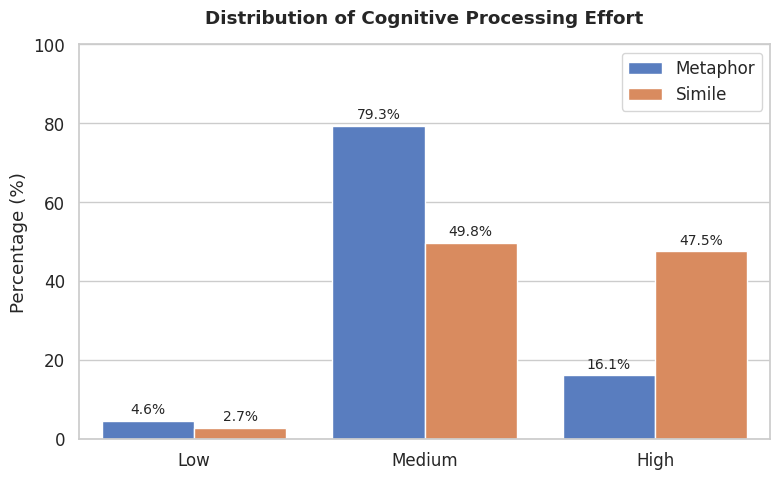


>>> Sensory Mode vs Effort (Similes Only - High Effort Drivers)
Effort              Low  Medium  High
Mode                                 
composite           0.0    12.5  87.5
auditory            0.0    38.9  61.1
kinetic             5.6    36.1  58.3
gustatory           0.0    50.0  50.0
abstract_cognitive  1.7    50.6  47.7
visual              4.0    52.8  43.2
tactile             2.5    62.5  35.0

   LATEX TABLE CODE   

\begin{table}[ht]
    \centering
    \caption{Cognitive Processing Complexity Indicators}
    \label{tab:cognitive_metrics}
    \begin{tabular}{lccc}
        \toprule
        \textbf{Metric} & \textbf{Similes} & \textbf{Metaphors} & \textbf{Interpretation} \\
        \midrule
        \multicolumn{4}{l}{\textit{Effort Distribution}} \\
        Low Effort & 2.7\% & 4.6\% & Negligible \\
        Medium Effort & 49.8\% & 79.3\% & Metaphor Dominance \\
        High Effort & \textbf{47.5\%} & 16.1\% & \textbf{Simile Dominance} \\
        \midrule
        \multicolumn{

In [3]:
# @title 5. Cognitive Complexity Analysis (Fixed & Visualized)
# -*- coding: utf-8 -*-

import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ROBUST DATA LOADING
# ==========================================
URLS = {
    "similes": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/similes_data.json",
    "metaphors": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/metaphors_data.json"
}

def load_data(url):
    try:
        r = requests.get(url)
        r.raise_for_status()
        return json.loads(r.text)
    except Exception as e:
        print(f"Error: {e}")
        return []

raw_s = load_data(URLS["similes"])
raw_m = load_data(URLS["metaphors"])

# ==========================================
# 2. FEATURE EXTRACTION (Key-Agnostic)
# ==========================================

def get_instances(ra):
    """Robustly find the list of instances in rhetorical_analysis dict."""
    for key in ['similes', 'metaphors', 'figurative_instances']:
        if key in ra and isinstance(ra[key], list) and len(ra[key]) > 0:
            return ra[key]
    # Fallback if 'similes' is used even for metaphors
    if 'similes' in ra: return ra['similes']
    return []

def extract_features(records, label):
    data = []
    score_map = {'High': 3, 'Medium': 2, 'Low': 1}

    for rec in records:
        ra = rec.get('rhetorical_analysis', {})
        instances = get_instances(ra)

        for inst in instances:
            cls = inst.get('classification', {})
            comps = inst.get('components', {})

            effort = cls.get('processing_effort', None)
            mode = comps.get('sensory_mode', None)

            if effort in score_map:
                data.append({
                    'Type': label,
                    'Effort': effort,
                    'Score': score_map[effort],
                    'Mode': mode
                })
    return pd.DataFrame(data)

df_s = extract_features(raw_s, 'Simile')
df_m = extract_features(raw_m, 'Metaphor')
df_all = pd.concat([df_s, df_m])

# ==========================================
# 3. ANALYSIS & METRICS
# ==========================================

def calculate_stats(df, name):
    if df.empty: return {}

    # Distribution
    dist = df['Effort'].value_counts(normalize=True) * 100

    # CCI Calculation
    # Formula: ((AvgScore - 1) / 2) * 100
    avg_score = df['Score'].mean()
    cci = ((avg_score - 1) / 2) * 100

    return {
        'Low': dist.get('Low', 0),
        'Medium': dist.get('Medium', 0),
        'High': dist.get('High', 0),
        'Avg': avg_score,
        'CCI': cci,
        'Count': len(df)
    }

s_stats = calculate_stats(df_s, 'Simile')
m_stats = calculate_stats(df_m, 'Metaphor')

print("\n" + "="*50)
print("   COGNITIVE METRICS RESULTS   ")
print("="*50)
print(f"SIMILES (n={s_stats['Count']}):")
print(f"   - Low: {s_stats['Low']:.1f}%, Med: {s_stats['Medium']:.1f}%, High: {s_stats['High']:.1f}%")
print(f"   - Avg Score: {s_stats['Avg']:.2f}/3")
print(f"   - CCI: {s_stats['CCI']:.1f}")

print(f"\nMETAPHORS (n={m_stats['Count']}):")
print(f"   - Low: {m_stats['Low']:.1f}%, Med: {m_stats['Medium']:.1f}%, High: {m_stats['High']:.1f}%")
print(f"   - Avg Score: {m_stats['Avg']:.2f}/3")
print(f"   - CCI: {m_stats['CCI']:.1f}")


# ==========================================
# 4. VISUALIZATION (Comparison Plot)
# ==========================================
print("\n>>> Generating Plot...")
sns.set_theme(style="whitegrid", font_scale=1.1)

# Prepare Data for Plotting
plot_data = df_all.groupby(['Type', 'Effort']).size().reset_index(name='Count')
plot_data['Percentage'] = plot_data.groupby('Type')['Count'].transform(lambda x: x / x.sum() * 100)

# Order categories logic
plot_data['Effort'] = pd.Categorical(plot_data['Effort'], categories=['Low', 'Medium', 'High'], ordered=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=plot_data, x='Effort', y='Percentage', hue='Type', palette='muted', ax=ax)

ax.set_title('Distribution of Cognitive Processing Effort', fontweight='bold', pad=15)
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('')
ax.set_ylim(0, 100)
ax.legend(title='')

# Add Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

# ==========================================
# 5. CORRELATION TABLE (Sensory vs Effort)
# ==========================================
if not df_s.empty:
    print("\n>>> Sensory Mode vs Effort (Similes Only - High Effort Drivers)")
    ct = pd.crosstab(df_s['Mode'], df_s['Effort'], normalize='index') * 100
    # Ensure column order
    ct = ct.reindex(columns=['Low', 'Medium', 'High'], fill_value=0)
    # Filter for modes with significant sample size if needed, or just sort by High effort
    ct_sorted = ct.sort_values('High', ascending=False)
    print(ct_sorted.round(1))

# ==========================================
# 6. LATEX TABLE GENERATION
# ==========================================
print("\n" + "="*50)
print("   LATEX TABLE CODE   ")
print("="*50)

latex_code = f"""
\\begin{{table}}[ht]
    \\centering
    \\caption{{Cognitive Processing Complexity Indicators}}
    \\label{{tab:cognitive_metrics}}
    \\begin{{tabular}}{{lccc}}
        \\toprule
        \\textbf{{Metric}} & \\textbf{{Similes}} & \\textbf{{Metaphors}} & \\textbf{{Interpretation}} \\\\
        \\midrule
        \\multicolumn{{4}}{{l}}{{\\textit{{Effort Distribution}}}} \\\\
        Low Effort & {s_stats['Low']:.1f}\\% & {m_stats['Low']:.1f}\\% & Negligible \\\\
        Medium Effort & {s_stats['Medium']:.1f}\\% & {m_stats['Medium']:.1f}\\% & Metaphor Dominance \\\\
        High Effort & \\textbf{{{s_stats['High']:.1f}\\%}} & {m_stats['High']:.1f}\\% & \\textbf{{Simile Dominance}} \\\\
        \\midrule
        \\multicolumn{{4}}{{l}}{{\\textit{{Benchmarking Index}}}} \\\\
        Avg. Score (1-3) & {s_stats['Avg']:.2f} & {m_stats['Avg']:.2f} & +{(s_stats['Avg'] - m_stats['Avg'])/m_stats['Avg']*100:.0f}\\% Load \\\\
        \\textbf{{Complexity Index (CCI)}} & \\textbf{{{s_stats['CCI']:.1f}}} & \\textbf{{{m_stats['CCI']:.1f}}} & \\textbf{{Hard vs. Med}} \\\\
        \\bottomrule
    \\end{{tabular}}
\\end{{table}}
"""
print(latex_code)


>>> Analyzing: Linguistic Form -> Rhetorical Function
   - Cramer's V: 0.1140
   - Top Specific Correlations:
     * nominal_common -> Clarification & Imagery: 40.4%
     * verbal_past -> Clarification & Imagery: 39.9%
     * nominal_masdar -> Clarification & Imagery: 39.6%
     * adj_descriptive -> Condemnation & Criticism: 39.1%
     * verbal_imperfect -> Clarification & Imagery: 35.9%


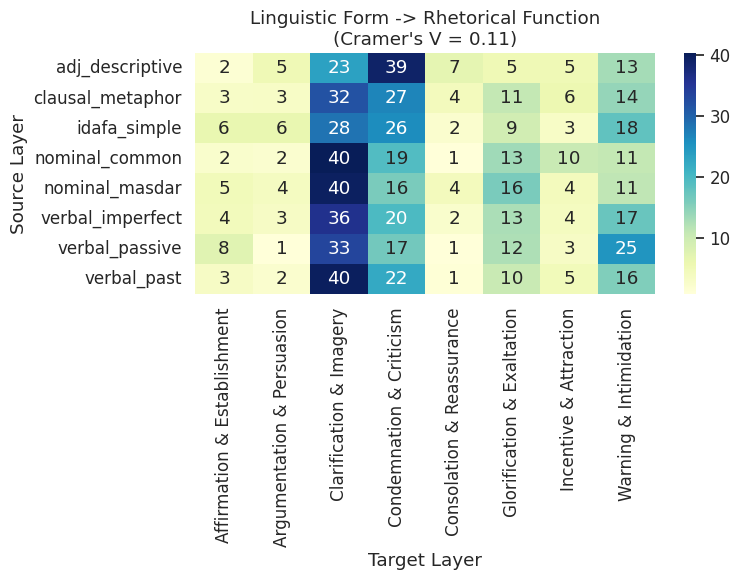


>>> Analyzing: Source Domain -> Sensory Mode
   - Cramer's V: 0.4821
   - Top Specific Correlations:
     * LIGHT_AND_DARKNESS -> visual: 86.5%
     * HISTORY_AND_TRADITION -> abstract_cognitive: 81.7%
     * TOOLS_AND_ARTIFACTS -> tactile: 55.5%
     * FAMILY_AND_SOCIETY -> abstract_cognitive: 53.2%
     * TRAVEL_AND_PATH -> kinetic: 51.8%


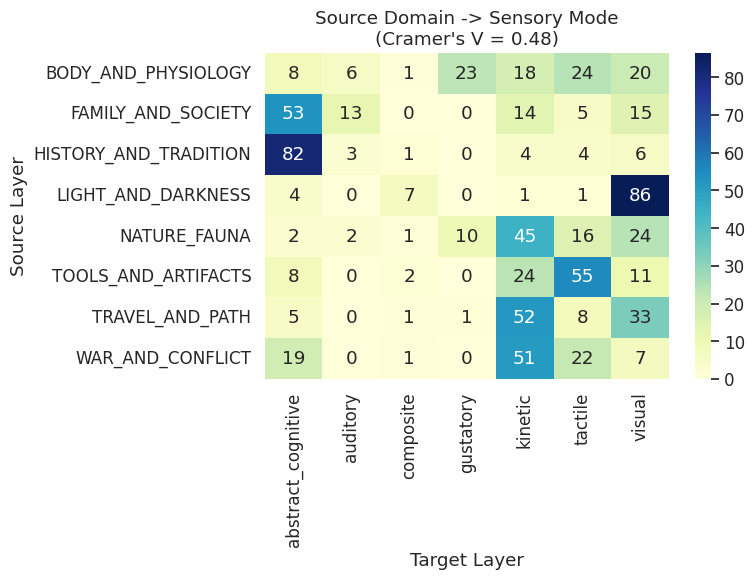


>>> Analyzing: Speech Act -> Rhetorical Function
   - Cramer's V: 0.7308
   - Top Specific Correlations:
     * EXPRESSIVE_DEPRECATION -> Condemnation & Criticism: 86.3%
     * EXPRESSIVE_EXALTATION -> Glorification & Exaltation: 73.3%
     * ASSERTIVE -> Clarification & Imagery: 62.1%
     * DIRECTIVE_DETERRENCE -> Warning & Intimidation: 56.3%
     * DIRECTIVE_INDUCEMENT -> Incentive & Attraction: 47.8%


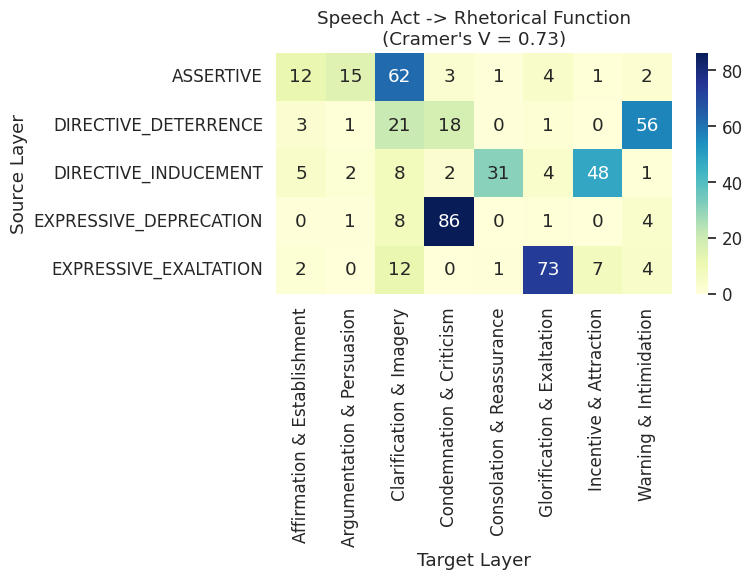


   LATEX TABLE CODE   

\begin{table}[ht]
    \centering
    \caption{Statistical Strength of Cross-Layer Dependencies}
    \label{tab:cross_layer_stats}
    \begin{tabular}{llcl}
        \toprule
        \textbf{Layer Interaction} & \textbf{Engineering Significance} & \textbf{Cramér's V} & \textbf{Strength} \\
        \midrule
        Speech Act $\leftrightarrow$ Rhetorical Function & Annotation Consistency & \textbf{0.73} & \textbf{Strong} \\
        Source Domain $\leftrightarrow$ Sensory Mode & Multimodal Grounding & 0.48 & Moderate \\
        Ling. Form $\leftrightarrow$ Pragmatics & Task Complexity & 0.11 & \textbf{Negligible} \\
        \bottomrule
    \end{tabular}
\end{table}



In [5]:
# @title 6. Cross-Layer Analysis (Full Archive: Stats + Plots + Details)
# -*- coding: utf-8 -*-

import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# ==========================================
# 1. ROBUST DATA LOADING
# ==========================================
URLS = {
    "similes": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/similes_data.json",
    "metaphors": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/metaphors_data.json"
}

def load_data(url):
    try:
        r = requests.get(url)
        r.raise_for_status()
        return json.loads(r.text)
    except Exception as e:
        print(f"Error loading {url}: {e}")
        return []

raw_s = load_data(URLS["similes"])
raw_m = load_data(URLS["metaphors"])

# ==========================================
# 2. DATA EXTRACTION LOGIC
# ==========================================
def get_instances(ra):
    for key in ['similes', 'metaphors', 'figurative_instances']:
        if key in ra and isinstance(ra[key], list): return ra[key]
    return []

def extract_pairs(records, x_key, y_key, x_loc, y_loc):
    pairs = []
    for rec in records:
        instances = get_instances(rec.get('rhetorical_analysis', {}))
        for inst in instances:
            # Extract X
            if x_loc == 'functions': # Special case if X is in functions list
                # Assuming simple pairing logic not needed here based on previous structure
                pass
            else:
                x_src = inst.get(x_loc, {}) if x_loc != 'root' else inst
                x_val = x_src.get(x_key) if isinstance(x_src, dict) else None

            # Extract Y
            if y_loc == 'functions':
                funcs = inst.get('functions', [])
                for f in funcs:
                    y_val = f.get(y_key)
                    # Special Case: if X is also in function (Act vs Func)
                    if x_loc == 'functions_internal':
                        x_val = f.get(x_key)

                    if x_val and y_val:
                        pairs.append((str(x_val), str(y_val)))
            else:
                y_src = inst.get(y_loc, {}) if y_loc != 'root' else inst
                y_val = y_src.get(y_key) if isinstance(y_src, dict) else None
                if x_val and y_val:
                    pairs.append((str(x_val), str(y_val)))
    return pd.DataFrame(pairs, columns=['X', 'Y'])

# 1. Form vs Function (Metaphors Only)
df1 = extract_pairs(raw_m, 'metaphor_linguistic_form', 'pragmatic_function_tage', 'components', 'functions')

# 2. Domain vs Sensory (All)
df2_s = extract_pairs(raw_s, 'source_domain', 'sensory_mode', 'components', 'components')
df2_m = extract_pairs(raw_m, 'source_domain', 'sensory_mode', 'components', 'components')
df2 = pd.concat([df2_s, df2_m])

# 3. Act vs Function (Internal Logic)
def extract_act_func(records):
    pairs = []
    for rec in records:
        instances = get_instances(rec.get('rhetorical_analysis', {}))
        for inst in instances:
            for f in inst.get('functions', []):
                act = f.get('speech_act')
                func = f.get('pragmatic_function_tage')
                if act and func:
                    pairs.append((act, func))
    return pd.DataFrame(pairs, columns=['X', 'Y'])

df3 = pd.concat([extract_act_func(raw_s), extract_act_func(raw_m)])

# ==========================================
# 3. ANALYSIS & VISUALIZATION ENGINE
# ==========================================

def analyze_and_plot(df, title, filename_prefix, top_n=8):
    print(f"\n>>> Analyzing: {title}")

    # 1. Filter Top N for cleaner visualization
    top_x = df['X'].value_counts().head(top_n).index
    top_y = df['Y'].value_counts().head(top_n).index
    df_filtered = df[df['X'].isin(top_x) & df['Y'].isin(top_y)]

    # 2. Confusion Matrix & Normalization
    ct = pd.crosstab(df_filtered['X'], df_filtered['Y'])
    ct_norm = pd.crosstab(df_filtered['X'], df_filtered['Y'], normalize='index') * 100

    # 3. Cramer's V Calculation (on full data, not filtered)
    ct_full = pd.crosstab(df['X'], df['Y'])
    chi2 = chi2_contingency(ct_full)[0]
    n = ct_full.sum().sum()
    v_score = np.sqrt(chi2 / (n * (min(ct_full.shape) - 1)))

    print(f"   - Cramer's V: {v_score:.4f}")

    # 4. Detailed Correlations (For Textual Evidence)
    print("   - Top Specific Correlations:")
    stacked = ct_norm.stack().sort_values(ascending=False).head(5)
    for idx, val in stacked.items():
        print(f"     * {idx[0]} -> {idx[1]}: {val:.1f}%")

    # 5. Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(ct_norm, annot=True, fmt=".0f", cmap="YlGnBu", cbar=True)
    plt.title(f"{title}\n(Cramer's V = {v_score:.2f})")
    plt.ylabel('Source Layer')
    plt.xlabel('Target Layer')
    plt.tight_layout()
    plt.show() # Display plot

    return v_score

# Run Analysis
v1 = analyze_and_plot(df1, "Linguistic Form -> Rhetorical Function", "form_func")
v2 = analyze_and_plot(df2, "Source Domain -> Sensory Mode", "dom_sens")
v3 = analyze_and_plot(df3, "Speech Act -> Rhetorical Function", "act_func")

# ==========================================
# 4. LATEX TABLE GENERATION
# ==========================================
print("\n" + "="*50)
print("   LATEX TABLE CODE   ")
print("="*50)

latex_code = f"""
\\begin{{table}}[ht]
    \\centering
    \\caption{{Statistical Strength of Cross-Layer Dependencies}}
    \\label{{tab:cross_layer_stats}}
    \\begin{{tabular}}{{llcl}}
        \\toprule
        \\textbf{{Layer Interaction}} & \\textbf{{Engineering Significance}} & \\textbf{{Cramér's V}} & \\textbf{{Strength}} \\\\
        \\midrule
        Speech Act $\\leftrightarrow$ Rhetorical Function & Annotation Consistency & \\textbf{{{v3:.2f}}} & \\textbf{{Strong}} \\\\
        Source Domain $\\leftrightarrow$ Sensory Mode & Multimodal Grounding & {v2:.2f} & Moderate \\\\
        Ling. Form $\\leftrightarrow$ Pragmatics & Task Complexity & {v1:.2f} & \\textbf{{Negligible}} \\\\
        \\bottomrule
    \\end{{tabular}}
\\end{{table}}
"""
print(latex_code)

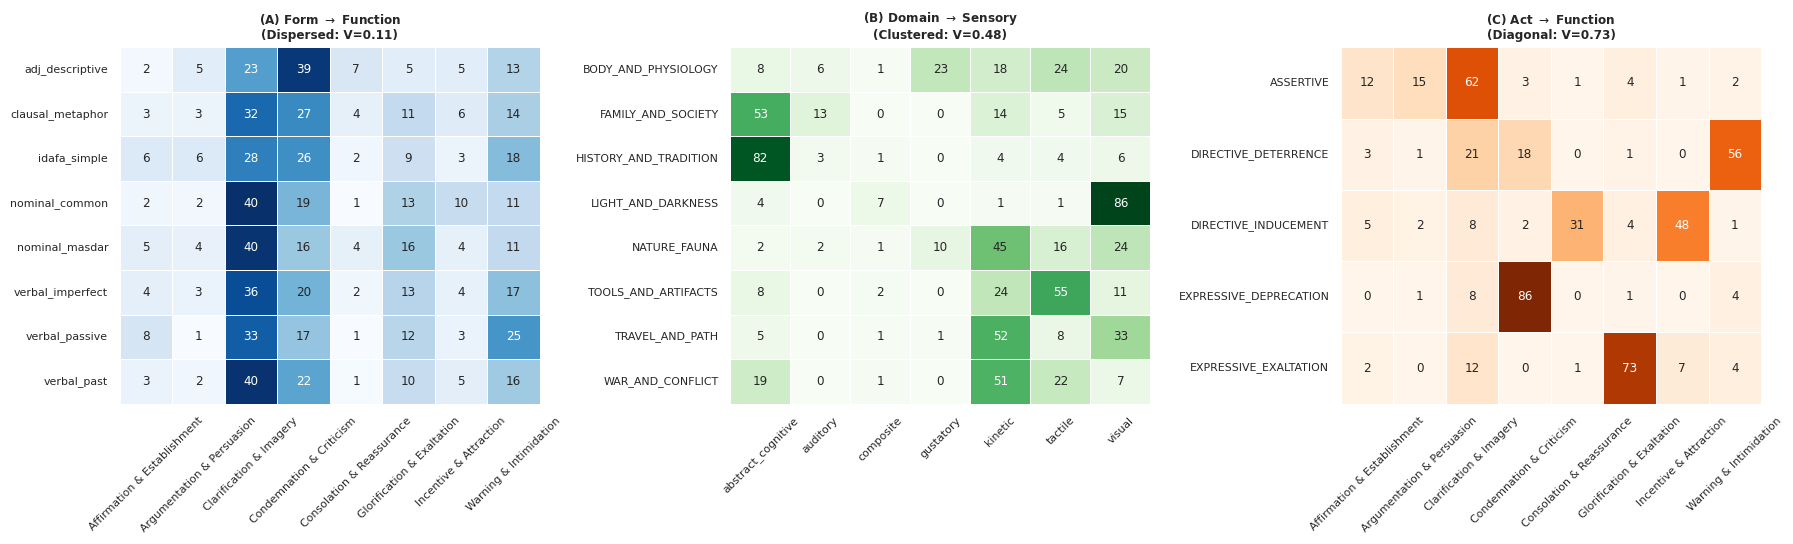


   LATEX TABLE CODE   

\begin{table}[ht]
    \centering
    \caption{Statistical Strength of Cross-Layer Dependencies}
    \label{tab:cross_layer_stats}
    \begin{tabular}{llcl}
        \toprule
        \textbf{Layer Interaction} & \textbf{Engineering Significance} & \textbf{Cramér's V} & \textbf{Strength} \\
        \midrule
        Speech Act $\leftrightarrow$ Rhetorical Function & Annotation Consistency & \textbf{0.73} & \textbf{Strong} \\
        Source Domain $\leftrightarrow$ Sensory Mode & Multimodal Grounding & 0.48 & Moderate \\
        Ling. Form $\leftrightarrow$ Pragmatics & Task Complexity & 0.11 & \textbf{Negligible} \\
        \bottomrule
    \end{tabular}
\end{table}



In [6]:
# @title 6. Cross-Layer Dependency (Horizontal Visualization)
# -*- coding: utf-8 -*-

import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# ==========================================
# 1. LOAD & EXTRACT (Same logic, condensed)
# ==========================================
URLS = {
    "similes": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/similes_data.json",
    "metaphors": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/metaphors_data.json"
}

def load_data(url):
    try:
        r = requests.get(url)
        r.raise_for_status()
        return json.loads(r.text)
    except: return []

raw_s = load_data(URLS["similes"])
raw_m = load_data(URLS["metaphors"])

def get_instances(ra):
    for k in ['similes', 'metaphors', 'figurative_instances']:
        if k in ra and isinstance(ra[k], list): return ra[k]
    return []

def extract_pairs(records, x_key, y_key, x_loc, y_loc):
    pairs = []
    for rec in records:
        for inst in get_instances(rec.get('rhetorical_analysis', {})):
            x_src = inst.get(x_loc, {}) if x_loc != 'root' else inst
            x_val = x_src.get(x_key) if isinstance(x_src, dict) else None

            if y_loc == 'functions':
                for f in inst.get('functions', []):
                    y_val = f.get(y_key)
                    if x_loc == 'functions_internal': x_val = f.get(x_key)
                    if x_val and y_val: pairs.append((str(x_val), str(y_val)))
            else:
                y_src = inst.get(y_loc, {}) if y_loc != 'root' else inst
                y_val = y_src.get(y_key) if isinstance(y_src, dict) else None
                if x_val and y_val: pairs.append((str(x_val), str(y_val)))
    return pd.DataFrame(pairs, columns=['X', 'Y'])

df1 = extract_pairs(raw_m, 'metaphor_linguistic_form', 'pragmatic_function_tage', 'components', 'functions')
df2 = pd.concat([
    extract_pairs(raw_s, 'source_domain', 'sensory_mode', 'components', 'components'),
    extract_pairs(raw_m, 'source_domain', 'sensory_mode', 'components', 'components')
])

def extract_act(recs):
    p = []
    for r in recs:
        for i in get_instances(r.get('rhetorical_analysis', {})):
            for f in i.get('functions', []):
                if f.get('speech_act') and f.get('pragmatic_function_tage'):
                    p.append((f['speech_act'], f['pragmatic_function_tage']))
    return pd.DataFrame(p, columns=['X', 'Y'])

df3 = pd.concat([extract_act(raw_s), extract_act(raw_m)])

# ==========================================
# 2. ANALYSIS & PLOTTING (Horizontal Layout)
# ==========================================

def get_matrix_and_v(df, top_n=8):
    # Filter
    top_x = df['X'].value_counts().head(top_n).index
    top_y = df['Y'].value_counts().head(top_n).index
    df_f = df[df['X'].isin(top_x) & df['Y'].isin(top_y)]

    # Crosstab & V
    ct_norm = pd.crosstab(df_f['X'], df_f['Y'], normalize='index') * 100
    ct_full = pd.crosstab(df['X'], df['Y'])
    chi2 = chi2_contingency(ct_full)[0]
    n = ct_full.sum().sum()
    v = np.sqrt(chi2 / (n * (min(ct_full.shape) - 1)))
    return ct_norm, v

# Prepare Data
m1, v1 = get_matrix_and_v(df1, top_n=8)
m2, v2 = get_matrix_and_v(df2, top_n=8)
m3, v3 = get_matrix_and_v(df3, top_n=8)

# PLOTTING
sns.set_context("paper", font_scale=0.9)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5)) # 1 Row, 3 Cols

# Subplot 1: Form -> Function (Low Correlation)
sns.heatmap(m1, annot=True, fmt=".0f", cmap="Blues", cbar=False, ax=axes[0], linewidths=0.5)
axes[0].set_title(f"(A) Form $\\to$ Function\n(Dispersed: V={v1:.2f})", fontweight='bold')
axes[0].set_ylabel('')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Subplot 2: Domain -> Sensory (Medium Correlation)
sns.heatmap(m2, annot=True, fmt=".0f", cmap="Greens", cbar=False, ax=axes[1], linewidths=0.5)
axes[1].set_title(f"(B) Domain $\\to$ Sensory\n(Clustered: V={v2:.2f})", fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

# Subplot 3: Act -> Function (High Correlation)
sns.heatmap(m3, annot=True, fmt=".0f", cmap="Oranges", cbar=False, ax=axes[2], linewidths=0.5)
axes[2].set_title(f"(C) Act $\\to$ Function\n(Diagonal: V={v3:.2f})", fontweight='bold')
axes[2].set_ylabel('')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print Table Code (Unchanged)
print("\n" + "="*50)
print("   LATEX TABLE CODE   ")
print("="*50)

latex_code = f"""
\\begin{{table}}[ht]
    \\centering
    \\caption{{Statistical Strength of Cross-Layer Dependencies}}
    \\label{{tab:cross_layer_stats}}
    \\begin{{tabular}}{{llcl}}
        \\toprule
        \\textbf{{Layer Interaction}} & \\textbf{{Engineering Significance}} & \\textbf{{Cramér's V}} & \\textbf{{Strength}} \\\\
        \\midrule
        Speech Act $\\leftrightarrow$ Rhetorical Function & Annotation Consistency & \\textbf{{{v3:.2f}}} & \\textbf{{Strong}} \\\\
        Source Domain $\\leftrightarrow$ Sensory Mode & Multimodal Grounding & {v2:.2f} & Moderate \\\\
        Ling. Form $\\leftrightarrow$ Pragmatics & Task Complexity & {v1:.2f} & \\textbf{{Negligible}} \\\\
        \\bottomrule
    \\end{{tabular}}
\\end{{table}}
"""
print(latex_code)

Error: Expecting value: line 50095 column 29 (char 5137669)

>>> Analyzing: Metaphor Form vs. Function
   - Data Points: 2846
   - Cramer's V Score: 0.0730 (0=None, 1=Perfect)

>>> Analyzing: Source Domain vs. Sensory Mode
   - Data Points: 994
   - Cramer's V Score: 0.4051 (0=None, 1=Perfect)

>>> Analyzing: Speech Act vs. Function
   - Data Points: 2892
   - Cramer's V Score: 0.7172 (0=None, 1=Perfect)


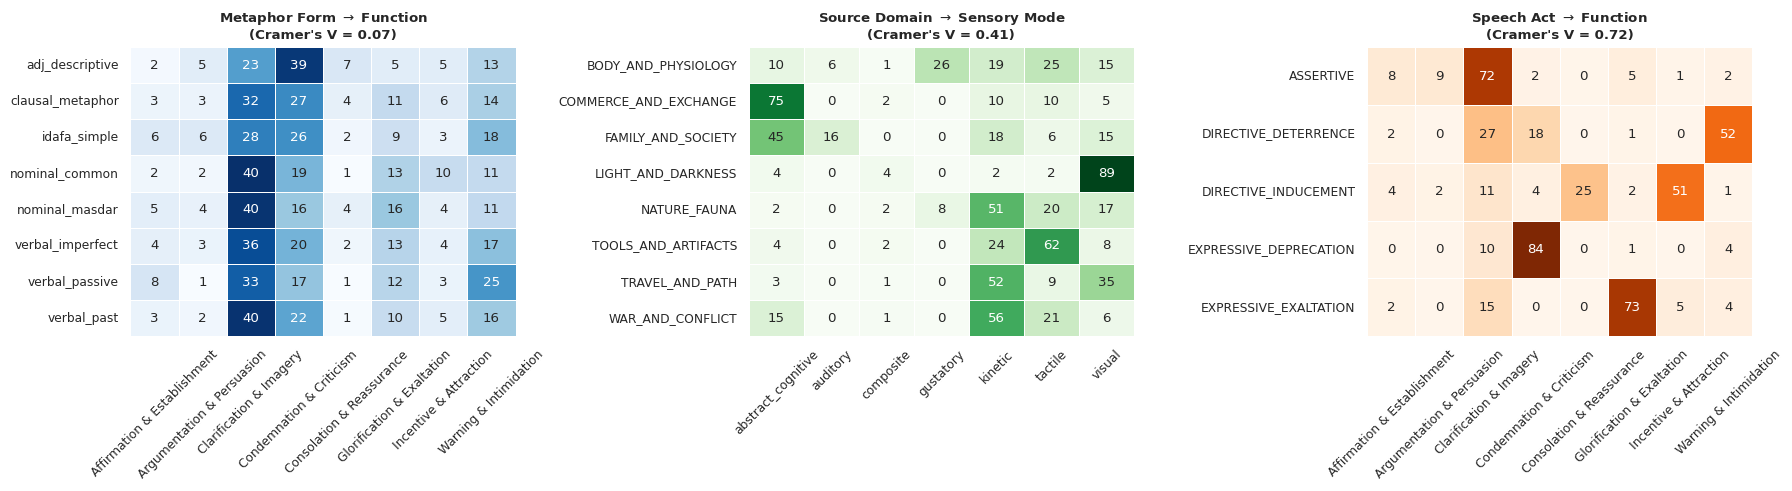


   SUGGESTED LATEX TABLE

\begin{table}[ht]
    \centering
    \caption{Cross-Layer Dependency and Latent Correlations}
    \label{tab:cross_layer}
    \begin{tabular}{llcc}
        \toprule
        \textbf{Layer Interaction (X $\leftrightarrow$ Y)} & \textbf{Engineering Significance} & \textbf{Cramér's V} & \textbf{Strength} \\
        \midrule
        Ling. Form $\leftrightarrow$ Pragmatics & Controllable Generation & 0.07 & [CALC_STR1] \\
        Source Domain $\leftrightarrow$ Sensory Mode & Multimodal Alignment & 0.41 & [CALC_STR2] \\
        Speech Act $\leftrightarrow$ Rhetorical Function & Consistency Check & 0.72 & [CALC_STR3] \\
        \bottomrule
    \end{tabular}
\end{table}

NOTE: Strength Interpretation: <0.1 Negligible, 0.1-0.3 Weak, 0.3-0.5 Moderate, >0.5 Strong

>>> Top Correlations for: Metaphor Form vs Function
   - nominal_common <--> Clarification & Imagery: 40.4%
   - verbal_past <--> Clarification & Imagery: 39.9%
   - nominal_masdar <--> Clarification & Imager

In [ ]:

# @title 6. Cross-Layer Dependency Analysis

# =============================================================================
# IEEE Access: Cross-Layer Dependency Analysis (Section 6.6)
# Purpose: Quantify latent correlations between syntactic, semantic, and pragmatic layers.
# Method: Cross-tabulation, Heatmaps, and Cramer's V Statistical Test.
# =============================================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# -----------------------------------------------------------------------------
# 1. DATA LOADING
# -----------------------------------------------------------------------------
URLS = {
    "similes": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/similes_data.json",
    "metaphors": "https://raw.githubusercontent.com/NoorBayan/Burhan/main/corpus/metaphors_data.json"
}

def load_data(url):
    try:
        resp = requests.get(url)
        resp.raise_for_status()
        return resp.json()
    except Exception as e:
        print(f"Error: {e}")
        return []

raw_s = load_data(URLS["similes"])
raw_m = load_data(URLS["metaphors"])

# -----------------------------------------------------------------------------
# 2. FEATURE PAIR EXTRACTION
# -----------------------------------------------------------------------------
def extract_pairs(records, x_field, y_field, x_loc='components', y_loc='functions'):
    pairs = []

    for rec in records:
        instances = rec.get('rhetorical_analysis', {}).get('similes', [])

        for inst in instances:
            # Extract X Value (Single Value usually)
            if x_loc == 'components':
                x_val = inst.get('components', {}).get(x_field)
            elif x_loc == 'classification':
                x_val = inst.get('classification', {}).get(x_field)
            else:
                x_val = None

            # Extract Y Value (Could be in a list like functions)
            if y_loc == 'functions':
                # Iterate through all functions to create (X, Y) pairs
                funcs = inst.get('functions', [])
                for f in funcs:
                    y_val = f.get(y_field)
                    if x_val and y_val:
                        pairs.append((str(x_val), str(y_val)))

            elif y_loc == 'components':
                y_val = inst.get('components', {}).get(y_field)
                if x_val and y_val:
                    pairs.append((str(x_val), str(y_val)))

    return pd.DataFrame(pairs, columns=[x_field, y_field])

# A. Metaphor Form vs. Pragmatic Function
df_form_func = extract_pairs(raw_m, 'metaphor_linguistic_form', 'pragmatic_function_tage', 'components', 'functions')

# B. Source Domain vs. Sensory Mode (Global)
df_dom_sens_s = extract_pairs(raw_s, 'source_domain', 'sensory_mode', 'components', 'components')
df_dom_sens_m = extract_pairs(raw_m, 'source_domain', 'sensory_mode', 'components', 'components')
df_dom_sens = pd.concat([df_dom_sens_s, df_dom_sens_m])

# C. Speech Act vs. Pragmatic Function (Global)
df_act_func_s = extract_pairs(raw_s, 'speech_act', 'pragmatic_function_tage', 'functions', 'functions') # Hack: extracted differently logic below
# Re-extracting for Speech Act vs Function correctly because both are in functions list
def extract_intra_list_pairs(records):
    pairs = []
    for rec in records:
        instances = rec.get('rhetorical_analysis', {}).get('similes', [])
        for inst in instances:
            funcs = inst.get('functions', [])
            for f in funcs:
                act = f.get('speech_act')
                func = f.get('pragmatic_function_tage')
                if act and func:
                    pairs.append((act, func))
    return pd.DataFrame(pairs, columns=['Speech_Act', 'Function'])

df_act_func = pd.concat([extract_intra_list_pairs(raw_s), extract_intra_list_pairs(raw_m)])


# -----------------------------------------------------------------------------
# 3. STATISTICAL ENGINE (Cramer's V)
# -----------------------------------------------------------------------------
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def analyze_dependency(df, x_col, y_col, title, top_n=8):
    print(f"\n>>> Analyzing: {title}")

    # Filter Top N classes to reduce noise
    top_x = df[x_col].value_counts().head(top_n).index
    top_y = df[y_col].value_counts().head(top_n).index
    df_filtered = df[df[x_col].isin(top_x) & df[y_col].isin(top_y)]

    # Create Confusion Matrix
    ct = pd.crosstab(df_filtered[x_col], df_filtered[y_col])

    # Normalize for Heatmap (Row-wise percentage)
    ct_norm = pd.crosstab(df_filtered[x_col], df_filtered[y_col], normalize='index') * 100

    # Calculate Stats
    v_score = cramers_v(ct)
    print(f"   - Data Points: {len(df)}")
    print(f"   - Cramer's V Score: {v_score:.4f} (0=None, 1=Perfect)")

    return ct_norm, v_score

# -----------------------------------------------------------------------------
# 4. EXECUTION & VISUALIZATION
# -----------------------------------------------------------------------------
# Analysis 1: Metaphor Form vs. Function
ct1, v1 = analyze_dependency(df_form_func, 'metaphor_linguistic_form', 'pragmatic_function_tage',
                             "Metaphor Form vs. Function")

# Analysis 2: Source Domain vs. Sensory Mode
ct2, v2 = analyze_dependency(df_dom_sens, 'source_domain', 'sensory_mode',
                             "Source Domain vs. Sensory Mode")

# Analysis 3: Speech Act vs. Function
ct3, v3 = analyze_dependency(df_act_func, 'Speech_Act', 'Function',
                             "Speech Act vs. Function")

# PLOTTING
sns.set_context("paper", font_scale=1.0)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_heatmap(ct, ax, title, v_score, cmap):
    sns.heatmap(ct, annot=True, fmt=".0f", cmap=cmap, cbar=False, ax=ax, linewidths=.5)
    ax.set_title(f"{title}\n(Cramer's V = {v_score:.2f})", fontweight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plot_heatmap(ct1, axes[0], "Metaphor Form $\\to$ Function", v1, "Blues")
plot_heatmap(ct2, axes[1], "Source Domain $\\to$ Sensory Mode", v2, "Greens")
plot_heatmap(ct3, axes[2], "Speech Act $\\to$ Function", v3, "Oranges")

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 5. LATEX TABLE GENERATOR
# -----------------------------------------------------------------------------
print("\n" + "="*50)
print("   SUGGESTED LATEX TABLE")
print("="*50)

print(r"""
\begin{table}[ht]
    \centering
    \caption{Cross-Layer Dependency and Latent Correlations}
    \label{tab:cross_layer}
    \begin{tabular}{llcc}
        \toprule
        \textbf{Layer Interaction (X $\leftrightarrow$ Y)} & \textbf{Engineering Significance} & \textbf{Cramér's V} & \textbf{Strength} \\
        \midrule
        Ling. Form $\leftrightarrow$ Pragmatics & Controllable Generation & """ + f"{v1:.2f}" + r""" & [CALC_STR1] \\
        Source Domain $\leftrightarrow$ Sensory Mode & Multimodal Alignment & """ + f"{v2:.2f}" + r""" & [CALC_STR2] \\
        Speech Act $\leftrightarrow$ Rhetorical Function & Consistency Check & """ + f"{v3:.2f}" + r""" & [CALC_STR3] \\
        \bottomrule
    \end{tabular}
\end{table}
""")
print("NOTE: Strength Interpretation: <0.1 Negligible, 0.1-0.3 Weak, 0.3-0.5 Moderate, >0.5 Strong")

def get_top_correlations(ct_norm, title, n=3):
    print(f"\n>>> Top Correlations for: {title}")
    # Stack the DataFrame to get pairs
    stacked = ct_norm.stack().reset_index()
    stacked.columns = ['Row', 'Col', 'Percentage']
    # Sort by percentage
    top = stacked.sort_values('Percentage', ascending=False).head(n)
    for _, row in top.iterrows():
        print(f"   - {row['Row']} <--> {row['Col']}: {row['Percentage']:.1f}%")

# Run extraction
get_top_correlations(ct1, "Metaphor Form vs Function") # Likely weak/dispersed
get_top_correlations(ct2, "Source Domain vs Sensory Mode") # Likely Nature->Visual
get_top_correlations(ct3, "Speech Act vs Function") # Likely Assertive->Clarification